In [3]:
import matplotlib.pyplot as plt
import numpy as np
import ctypes
from matplotlib.colors import Normalize


In [4]:
lib = ctypes.CDLL('./build/libpendulum.dylib')

In [5]:
# típusdeklaráció
lib.simulate_phi.argtypes = [
    ctypes.c_double, ctypes.c_double, ctypes.c_double, ctypes.c_double,  # L1, L2, M1, M2
    ctypes.c_double, ctypes.c_double, ctypes.c_double, ctypes.c_double,  # p1_0, p2_0, o1_0, o2_0
    ctypes.c_double, ctypes.c_double, ctypes.c_int,                      # T, h, use_phi1
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double), ctypes.c_size_t  # out_phi, out_time, len
]

lib.find_first_flip_time.argtypes = [
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double), ctypes.c_size_t
]
lib.find_first_flip_time.restype = ctypes.c_double

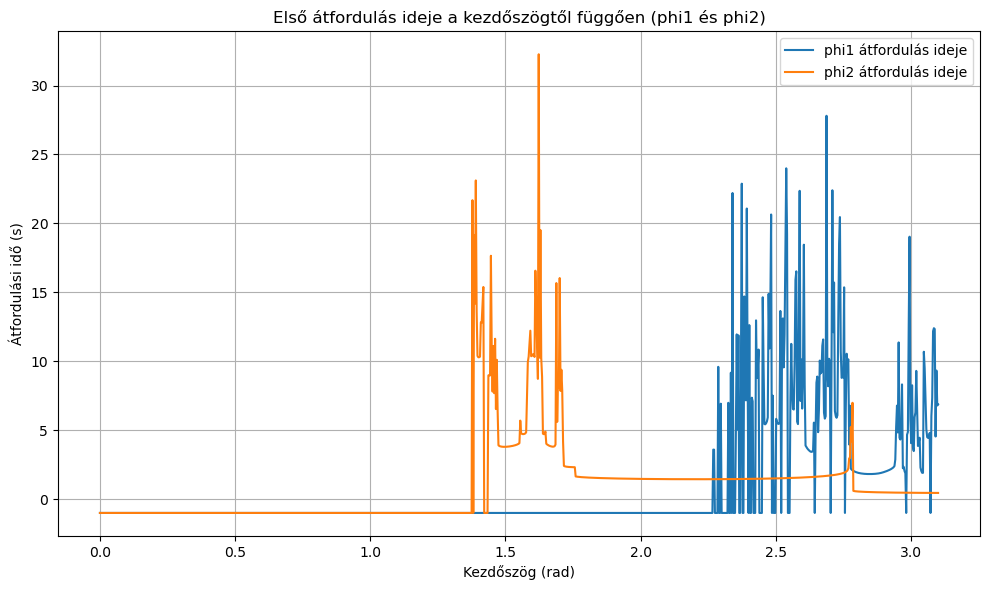

In [29]:
# Szimulációs paraméterek
T = 100.0
h = 0.001
N = int(T / h) + 1
l1 = 1
l2 =0.5
m1=1
m2=1

# omega10 omega20 nulla végig!!!


# Kezdőszögek
initial_phis = np.linspace(0, 3.1, 1000)
flip_times_phi1 = []
flip_times_phi2 = []

for phi0 in initial_phis:
    # Kimeneti tömbök
    phi_arr = np.zeros(N, dtype=np.float64)
    time_arr = np.zeros(N, dtype=np.float64)

    # phi1 szimuláció
    lib.simulate_phi(l1, l2, m1, m2, phi0, phi0, 0.0, 0.0,
                     T, h, 1,  # use_phi1 = 1
                     phi_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
                     time_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
                     N)
    flip1 = lib.find_first_flip_time(
        time_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        phi_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        N
    )

    # phi2 szimuláció
    phi_arr[:] = 0.0  # kinullázás
    time_arr[:] = 0.0
    lib.simulate_phi(1.0, 0.5, 1.0, 1.0, phi0, phi0, 0.0, 0.0,
                     T, h, 0,  # use_phi1 = 0
                     phi_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
                     time_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
                     N)
    flip2 = lib.find_first_flip_time(
        time_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        phi_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        N
    )

    flip_times_phi1.append(flip1)
    flip_times_phi2.append(flip2)

# Ábrázolás
plt.figure(figsize=(10, 6))
plt.plot(initial_phis, flip_times_phi1, label='phi1 átfordulás ideje')
plt.plot(initial_phis, flip_times_phi2, label='phi2 átfordulás ideje')
plt.xlabel('Kezdőszög (rad)')
plt.ylabel('Átfordulási idő (s)')
plt.title('Első átfordulás ideje a kezdőszögtől függően (phi1 és phi2)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("atf-1")
plt.show()


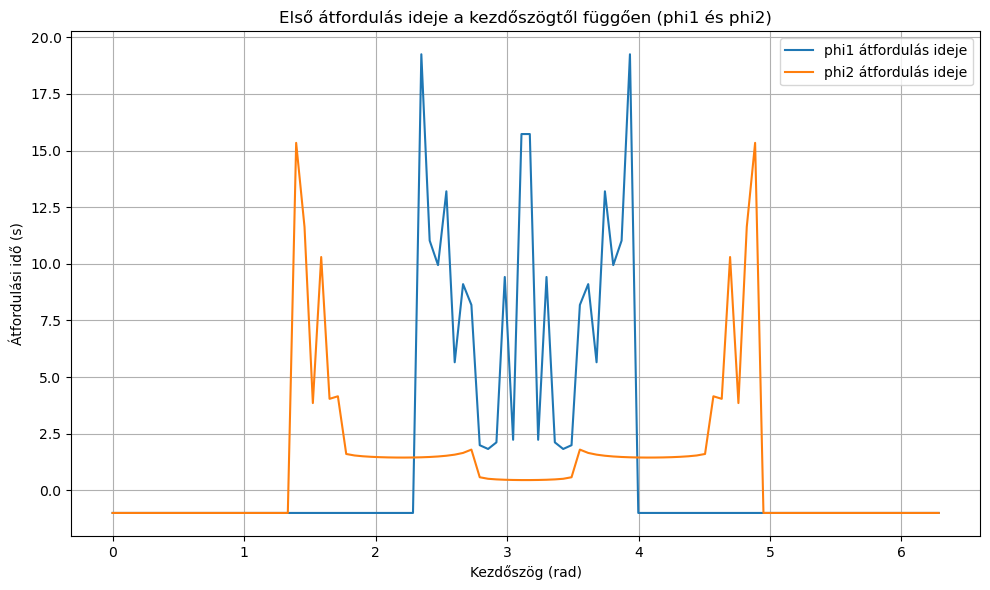

In [7]:
# Szimulációs paraméterek
T = 100.0
h = 0.001
N = int(T / h) + 1

# Kezdőszögek
initial_phis = np.linspace(0, np.pi*2, 100)
flip_times_phi1 = []
flip_times_phi2 = []

for phi0 in initial_phis:
    phi_arr = np.zeros(N, dtype=np.float64)
    time_arr = np.zeros(N, dtype=np.float64)

    # phi1 szimuláció
    lib.simulate_phi(l1, l2, m1, m2, phi0, phi0, 0.0, 0.0,
                     T, h, 1,  # use_phi1 = 1
                     phi_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
                     time_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
                     N)
    flip1 = lib.find_first_flip_time(
        time_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        phi_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        N
    )

    # phi2 szimuláció
    phi_arr[:] = 0.0  # kinullázás
    time_arr[:] = 0.0
    lib.simulate_phi(l1, l2, m1, m2, phi0, phi0, 0.0, 0.0,
                     T, h, 0,  # use_phi1 = 1
                     phi_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
                     time_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
                     N)
    flip2 = lib.find_first_flip_time(
        time_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        phi_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        N
    )

    flip_times_phi1.append(flip1)
    flip_times_phi2.append(flip2)

# Ábrázolás
plt.figure(figsize=(10, 6))
plt.plot(initial_phis, flip_times_phi1, label='phi1 átfordulás ideje')
plt.plot(initial_phis, flip_times_phi2, label='phi2 átfordulás ideje')
plt.xlabel('Kezdőszög (rad)')
plt.ylabel('Átfordulási idő (s)')
plt.title('Első átfordulás ideje a kezdőszögtől függően (phi1 és phi2)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("atf-2")
plt.show()


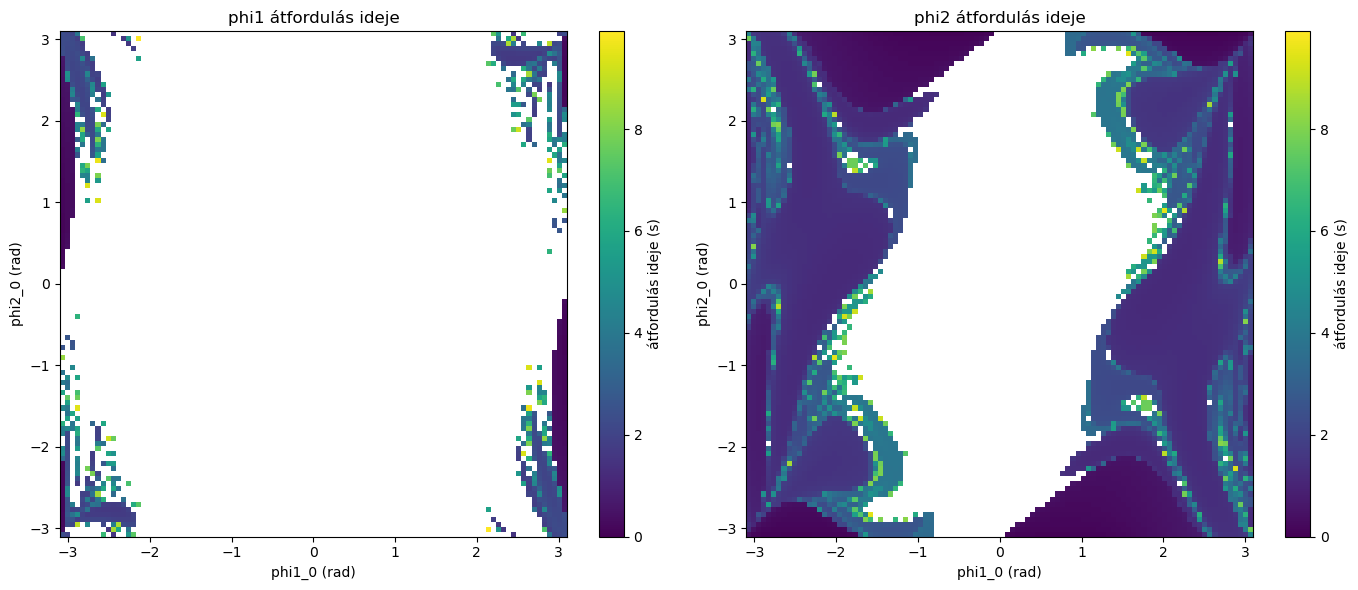

In [8]:
# Paraméterek
T = 10.0
h = 0.01
N = int(T / h) + 1

# Kezdőszög-rács (phi1_0 és phi2_0 külön)
phi_range = np.linspace(-3.1, 3.1, 100)
flip_times_phi1 = np.full((100, 100), -1.0)
flip_times_phi2 = np.full((100, 100), -1.0)

# Számolás: 2D rácsban
for i, phi1_0 in enumerate(phi_range):
    for j, phi2_0 in enumerate(phi_range):
        # Kimeneti tömbök
        phi_arr = np.zeros(N, dtype=np.float64)
        time_arr = np.zeros(N, dtype=np.float64)

        # --- phi1 átfordulás ---
        lib.simulate_phi(l1, l2, m1, m2, phi1_0, phi2_0, 0.0, 0.0,
                     T, h, 1,  # use_phi1 = 1
                     phi_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
                     time_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
                     N)

        flip1 = lib.find_first_flip_time(
            time_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
            phi_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
            N
        )
        flip_times_phi1[i, j] = flip1

        # --- phi2 átfordulás ---
        phi_arr[:] = 0.0
        time_arr[:] = 0.0
        lib.simulate_phi(l1, l2, m1, m2, phi1_0, phi2_0, 0.0, 0.0,
                     T, h, 0,  # use_phi1 = 0
                     phi_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
                     time_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
                     N)

        flip2 = lib.find_first_flip_time(
            time_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
            phi_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
            N
        )
        flip_times_phi2[i, j] = flip2

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
extent = [-3.1, 3.1, -3.1, 3.1]

masked_phi1 = np.ma.masked_less(flip_times_phi1, 0)
masked_phi2 = np.ma.masked_less(flip_times_phi2, 0)

vmax = np.nanmax([masked_phi1.max(), masked_phi2.max()])
norm = Normalize(vmin=0, vmax=vmax)

im1 = axs[0].imshow(masked_phi1.T, origin='lower', extent=extent,
                    aspect='auto', cmap='viridis', norm=norm)
axs[0].set_title('phi1 átfordulás ideje')
axs[0].set_xlabel('phi1_0 (rad)')
axs[0].set_ylabel('phi2_0 (rad)')
fig.colorbar(im1, ax=axs[0], label='átfordulás ideje (s)')

im2 = axs[1].imshow(masked_phi2.T, origin='lower', extent=extent,
                    aspect='auto', cmap='viridis', norm=norm)
axs[1].set_title('phi2 átfordulás ideje')
axs[1].set_xlabel('phi1_0 (rad)')
axs[1].set_ylabel('phi2_0 (rad)')
fig.colorbar(im2, ax=axs[1], label='átfordulás ideje (s)')

plt.tight_layout()
plt.savefig("atf-1-2")
plt.show()


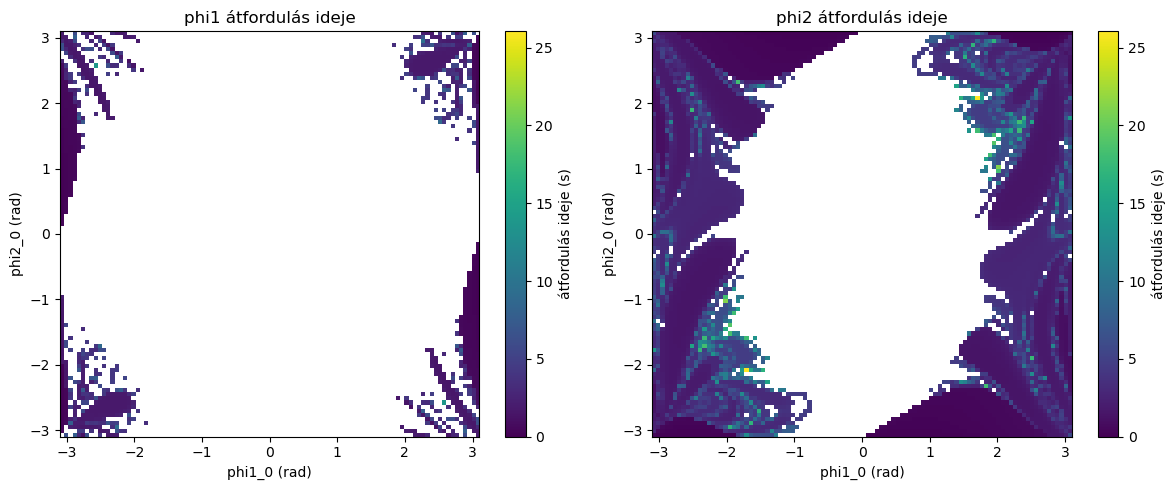

In [9]:
# Paraméterek
T = 100.0
h = 0.01
N = int(T / h) + 1

# Kezdőszög-rács (phi1_0 és phi2_0 külön)
phi_range = np.linspace(-3.1, 3.1, 100)
flip_times_phi1 = np.full((100, 100), -1.0)
flip_times_phi2 = np.full((100, 100), -1.0)

# Számolás: 2D rácsban
for i, phi1_0 in enumerate(phi_range):
    for j, phi2_0 in enumerate(phi_range):
        # Kimeneti tömbök
        phi_arr = np.zeros(N, dtype=np.float64)
        time_arr = np.zeros(N, dtype=np.float64)

        # --- phi1 átfordulás ---
        lib.simulate_phi(1.0, 1.0, 1.0, 1.0,
                         phi1_0, phi2_0, 0.0, 0.0,
                         T, h, 1,  # use_phi1 = 1
                         phi_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
                         time_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
                         N)

        flip1 = lib.find_first_flip_time(
            time_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
            phi_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
            N
        )
        flip_times_phi1[i, j] = flip1

        # --- phi2 átfordulás ---
        phi_arr[:] = 0.0
        time_arr[:] = 0.0
        lib.simulate_phi(1.0, 1.0, 1.0, 1.0,
                         phi1_0, phi2_0, 0.0, 0.0,
                         T, h, 0,  # use_phi1 = 0
                         phi_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
                         time_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
                         N)

        flip2 = lib.find_first_flip_time(
            time_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
            phi_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
            N
        )
        flip_times_phi2[i, j] = flip2

extent = [-3.1, 3.1, -3.1, 3.1]

masked_phi1 = np.ma.masked_less(flip_times_phi1, 0)
masked_phi2 = np.ma.masked_less(flip_times_phi2, 0)

vmax = np.nanmax([masked_phi1.max(), masked_phi2.max()])
norm = Normalize(vmin=0, vmax=vmax)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
im1 = axs[0].imshow(masked_phi1.T, origin='lower', extent=extent,
                    aspect='auto', cmap='viridis', norm=norm)
axs[0].set_title('phi1 átfordulás ideje')
axs[0].set_xlabel('phi1_0 (rad)')
axs[0].set_ylabel('phi2_0 (rad)')
fig.colorbar(im1, ax=axs[0], label='átfordulás ideje (s)')

im2 = axs[1].imshow(masked_phi2.T, origin='lower', extent=extent,
                    aspect='auto', cmap='viridis', norm=norm)
axs[1].set_title('phi2 átfordulás ideje')
axs[1].set_xlabel('phi1_0 (rad)')
axs[1].set_ylabel('phi2_0 (rad)')
fig.colorbar(im2, ax=axs[1], label='átfordulás ideje (s)')

plt.tight_layout()
plt.savefig("atf-2-2")

plt.show()

